# 4. Tweedie denoising and posterior uncertainty (Draft)

## The question

What does a score tell us about the clean value hidden behind a noisy observation? Does an optimal denoised estimate count as a sample from the clean distribution?

We will derive the posterior-mean connection, verify it analytically for a Gaussian mixture, and visualize the uncertainty that the posterior mean does not represent. We will also compare an exact score with a learned noise predictor.

**Background:** Bayes' rule, conditional expectation, Gaussian densities, and squared-error regression. **Setup:** NumPy, SciPy, Matplotlib, and PyTorch on a CPU. Run all cells in order. If Notebook 3's `toy-noise.pt` is present, this notebook reuses it; otherwise it trains its own small network. No external dataset is needed.

## 1. Define the clean and noisy distributions

Use the equally weighted mixture

$$p_0(x)=\tfrac12\mathcal N(x;-2,0.25)+\tfrac12\mathcal N(x;2,0.25).$$

Let $m_1=-2$, $m_2=2$, and $V_0=0.25$. With $\beta=8$, $\alpha_t=e^{-\beta t/2}$, and independent $\varepsilon\sim\mathcal N(0,1)$,

$$X_t=\alpha_tX_0+\sqrt{1-\alpha_t^2}\,\varepsilon.$$

Data time is 0 and terminal time is 1. Each noisy mixture component has mean $\alpha_t m_j$ and variance

$$V_t=\alpha_t^2V_0+1-\alpha_t^2.$$

The following helper cell defines the exact mixture density, responsibilities $w_j(x,t)$, and score

$$s_t(x)=\sum_jw_j(x,t)\frac{\alpha_tm_j-x}{V_t},\qquad
w_j(x,t)=\frac{\tfrac12\mathcal N(x;\alpha_tm_j,V_t)}{p_t(x)}.$$

These helpers also include the ODE sampler used elsewhere in the series, although the experiments below concern conditional denoising rather than trajectory generation.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp, ndtr
rng = np.random.default_rng(20260930)
started = time.perf_counter()
beta = 8.0
t_min = 0.01
means = np.array([-2., 2.])
V0 = 0.25

def alpha(t):
    return np.exp(-beta * np.asarray(t) / 2)

def parameters(t):
    a = alpha(t)
    return a * means, a*a*V0 + 1-a*a

def sample_data(n):
    return rng.choice(means, n) + np.sqrt(V0)*rng.normal(size=n)

def sample_marginal(n, t):
    a = alpha(t)
    return a*sample_data(n) + np.sqrt(1-a*a)*rng.normal(size=n)

def component_weights(x, t):
    m, V = parameters(t)
    logw = -(np.asarray(x)[..., None]-m)**2/(2*V)
    return np.exp(logw-logsumexp(logw, axis=-1, keepdims=True))

def density(x, t):
    m, V = parameters(t)
    return np.mean(np.exp(-(np.asarray(x)[...,None]-m)**2/(2*V))/np.sqrt(2*np.pi*V), axis=-1)

def cdf(x, t):
    m, V = parameters(t)
    return np.mean(ndtr((np.asarray(x)[...,None]-m)/np.sqrt(V)), axis=-1)

def score(x, t):
    m, V = parameters(t)
    return np.sum(component_weights(x,t)*(m-np.asarray(x)[...,None])/V, axis=-1)

def ecdf_error(x, t):
    x = np.sort(x)
    F = cdf(x,t)
    n = len(x)
    return max(np.max(np.arange(1,n+1)/n-F), np.max(F-np.arange(n)/n))

def sample_reverse(x1, steps=400, stochastic=False, score_fn=score, end=t_min, keep=8):
    x = np.asarray(x1).copy()
    times = np.linspace(1.,end,steps+1)
    traces = [x[:keep].copy()]
    for t, next_t in zip(times[:-1],times[1:]):
        h = t-next_t
        s = score_fn(x,t)
        # Increasing reverse clock: -f + g^2*s for SDE; half score for ODE.
        x += h*beta*(0.5*x+(1. if stochastic else 0.5)*s)
        if stochastic:
            x += np.sqrt(beta*h)*rng.normal(size=x.shape)
        traces.append(x[:keep].copy())
    return x, times, np.asarray(traces)


## 2. What does “Bayes-optimal denoising” mean?

For a fixed noisy observation $X_t=x$, choose a clean-value estimate $d$. Its conditional squared-error risk decomposes as

$$\mathbb E[(X_0-d)^2\mid X_t=x]
=\operatorname{Var}(X_0\mid X_t=x)
+\left(\mathbb E[X_0\mid X_t=x]-d\right)^2.$$

The cross term vanishes because the centered clean variable has conditional mean zero. Therefore the optimal estimate for squared error is

$$D_*(x,t)=\mathbb E[X_0\mid X_t=x].$$

This is a statement about a loss function. It does not say that the posterior is concentrated at this estimate or that the estimate must lie near one of its modes.

## 3. Derive Tweedie's formula

First consider additive Gaussian noise $Y=X+\sigma\varepsilon$. The likelihood derivative is

$$\partial_y p(y\mid x)=\frac{x-y}{\sigma^2}p(y\mid x).$$

Differentiate the marginal density and divide by it:

$$\begin{aligned}
\partial_y\log p_Y(y)
&=\frac{1}{p_Y(y)}\int\frac{x-y}{\sigma^2}p(y\mid x)p_X(x)\,dx\\
&=\frac1{\sigma^2}\int(x-y)p(x\mid y)\,dx\\
&=\frac{\mathbb E[X\mid Y=y]-y}{\sigma^2}.
\end{aligned}$$

The second line is Bayes' rule. Under the usual integrability conditions, rearranging gives

$$\mathbb E[X\mid Y=y]=y+\sigma^2\partial_y\log p_Y(y).$$

For diffusion corruption, apply this identity to the clean quantity $\alpha_tX_0$, with noise variance $1-\alpha_t^2$. When $\alpha_t>0$,

$$\boxed{D_*(x,t)=\frac{x+(1-\alpha_t^2)s_t(x)}{\alpha_t}.}$$

The score of the noisy marginal therefore determines the Bayes-optimal clean posterior mean.

## 4. Obtain a learned comparison

A noise predictor trained with mean squared error estimates $\mathbb E[\varepsilon\mid X_t=x]$. The identity

$$s_t(x)=-\frac{\mathbb E[\varepsilon\mid X_t=x]}{\sqrt{1-\alpha_t^2}}$$

converts it into a score. The next cell defines the same small CPU network and regression procedure used in Notebook 3. The training loss uses actual simulated noise draws; the exact score is only a reference for evaluation.

In [2]:
import torch
from torch import nn
torch.set_num_threads(2)
torch.manual_seed(20260930)

class NoiseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(6,64),nn.SiLU(),nn.Linear(64,64),nn.SiLU(),nn.Linear(64,1))
    def forward(self,x,t):
        features = torch.stack([x,t,torch.sin(np.pi*t),torch.cos(np.pi*t),torch.sin(2*np.pi*t),torch.cos(2*np.pi*t)],-1)
        return self.net(features).squeeze(-1)

def train_noise(steps=2500):
    model=NoiseNet()
    optimizer=torch.optim.Adam(model.parameters(),lr=2e-3)
    losses=[]
    for k in range(steps):
        x0=(torch.randint(0,2,(512,))*2-1).float()*2 + 0.5*torch.randn(512)
        t=t_min+(1-t_min)*torch.rand(512)
        a=torch.exp(-beta*t/2)
        eps=torch.randn(512)
        xt=a*x0+torch.sqrt(1-a*a)*eps
        loss=(model(xt,t)-eps).square().mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    model.eval()
    return model,np.asarray(losses)

def make_learned_score(model):
    @torch.no_grad()
    def learned_score(x,t):
        xx=torch.as_tensor(x,dtype=torch.float32)
        tt=torch.full_like(xx,float(t))
        return -model(xx,tt).numpy()/np.sqrt(1-alpha(t)**2)
    return learned_score


## 5. Compute the mixture posterior directly

To check Tweedie's formula independently, condition each Gaussian component. Given component $j$, the posterior has mean

$$\mu_{j\mid x,t}=m_j+
\frac{\alpha_tV_0}{V_t}(x-\alpha_tm_j)$$

and variance

$$V_{\mathrm{post},t}=\frac{V_0(1-\alpha_t^2)}{V_t}.$$

These follow from conditioning the jointly Gaussian pair $(X_0,X_t)$ within that component: their covariance is $\alpha_tV_0$. Bayes' rule gives the posterior component weights $w_j(x,t)$ already defined above. Hence

$$D_*(x,t)=\sum_jw_j(x,t)\mu_{j\mid x,t}.$$

At $t=0.15$, compare three curves: this direct posterior mean, Tweedie's formula with the exact score, and Tweedie's formula with the learned score. The first two should agree up to numerical precision; the third reveals model error.

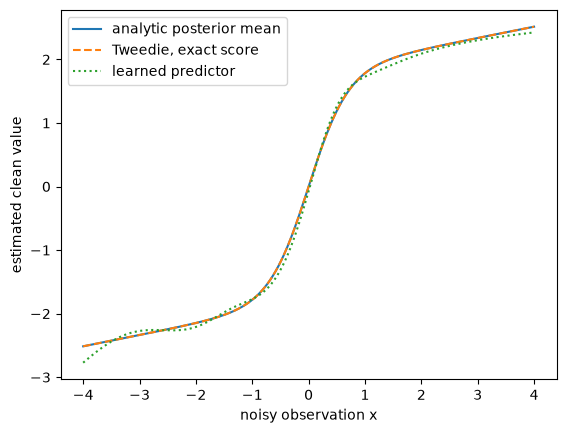

In [3]:
from pathlib import Path
if Path("toy-noise.pt").exists():
    checkpoint=torch.load("toy-noise.pt",map_location="cpu",weights_only=True)
    assert checkpoint["beta"]==beta and checkpoint["t_min"]==t_min
    model=NoiseNet(); model.load_state_dict(checkpoint["state_dict"]); model.eval()
else:
    model,_=train_noise()
learned_score=make_learned_score(model)
t=.15; a=alpha(t); _,V=parameters(t)
x=np.linspace(-4,4,500)
component_mean=means+a*V0/V*(x[:,None]-a*means)
posterior_mean=np.sum(component_weights(x,t)*component_mean,axis=1)
tweedie=(x+(1-a*a)*score(x,t))/a
learned_mean=(x+(1-a*a)*learned_score(x,t))/a
assert np.max(abs(tweedie-posterior_mean))<1e-12
plt.plot(x,posterior_mean,label="analytic posterior mean")
plt.plot(x,tweedie,'--',label="Tweedie, exact score")
plt.plot(x,learned_mean,':',label="learned predictor")
plt.xlabel("noisy observation x"); plt.ylabel("estimated clean value"); plt.legend(); plt.show()

### Reading the denoising curves

The analytic posterior mean and the exact-score Tweedie curve coincide; the code checks a maximum difference below $10^{-12}$. Their agreement connects a calculation based on posterior conditioning with one based on a local derivative of the noisy marginal. The learned curve approximates them but need not coincide.

## 6. An ambiguous observation: mean versus posterior sample

Set $x_t=0$ at the same time $t=0.15$. Symmetry makes the component weights equal and the posterior mean zero. The component posterior means, however, remain separated. Most posterior samples are near one of those components, rather than at zero.

To sample the posterior correctly for this known mixture:

1. Draw a component index $J$ with probabilities $w_1(0,t),w_2(0,t)$.
2. Draw fresh independent noise $\varepsilon\sim\mathcal N(0,1)$.
3. Return $\mu_{J\mid0,t}+\sqrt{V_{\mathrm{post},t}}\,\varepsilon$.

A single deterministic posterior-mean output omits both component uncertainty and within-component uncertainty.

## 7. Check how the three prediction losses are related

For any noise prediction $\widehat\varepsilon$, define

$$\widehat s=-\frac{\widehat\varepsilon}{\sqrt{1-\alpha_t^2}},
\qquad\widehat x_0=\frac{x_t-\sqrt{1-\alpha_t^2}\widehat\varepsilon}{\alpha_t}.$$

Because the simulated pair satisfies $x_t=\alpha_tx_0+\sqrt{1-\alpha_t^2}\varepsilon$, the errors obey

$$\begin{aligned}
(\varepsilon-\widehat\varepsilon)^2
&=(1-\alpha_t^2)\left(-\frac{\varepsilon}{\sqrt{1-\alpha_t^2}}-\widehat s\right)^2,\\
(x_0-\widehat x_0)^2
&=\frac{1-\alpha_t^2}{\alpha_t^2}(\varepsilon-\widehat\varepsilon)^2.
\end{aligned}$$

The next cell plots the conditional posterior samples and then verifies these identities on generated training pairs. The score target in the first identity is the **conditional corruption score**, not the exact marginal score. These are samplewise algebraic identities; they do not imply identical unweighted objectives across different noise levels.

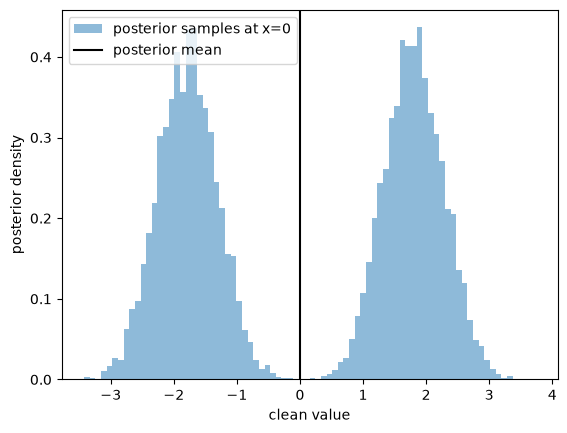

Tweedie identity and loss conversions verified.
Runtime: 0.4 s


In [4]:
# Condition on an ambiguous observation x=0. The posterior mean is zero.
observation=0.
weights=component_weights(observation,t)
post_means=means+a*V0/V*(observation-a*means)
post_var=V0*(1-a*a)/V
components=rng.choice(2,10000,p=weights)
posterior_samples=post_means[components]+np.sqrt(post_var)*rng.normal(size=10000)
plt.hist(posterior_samples,bins=80,density=True,alpha=.5,label="posterior samples at x=0")
plt.axvline(np.sum(weights*post_means),color="black",label="posterior mean")
plt.xlabel("clean value"); plt.ylabel("posterior density"); plt.legend(); plt.show()
# Verify the samplewise loss conversions for arbitrary model predictions.
x0=sample_data(1000); eps=rng.normal(size=1000); xt=a*x0+np.sqrt(1-a*a)*eps
s_hat=learned_score(xt,t)
eps_hat=-np.sqrt(1-a*a)*s_hat
x0_hat=(xt-np.sqrt(1-a*a)*eps_hat)/a
assert np.allclose((eps-eps_hat)**2,(1-a*a)*(-eps/np.sqrt(1-a*a)-s_hat)**2)
assert np.allclose((x0-x0_hat)**2,(1-a*a)/a**2*(eps-eps_hat)**2)
print("Tweedie identity and loss conversions verified.")
print(f"Runtime: {time.perf_counter()-started:.1f} s")

### Reading the posterior plot

The vertical line at zero is the squared-error optimal estimate. The histogram shows the two regions where the clean value is plausible given the noisy observation. Neither description contradicts the other: an estimate summarizes the posterior according to a loss, whereas a sample preserves its uncertainty.

There is a useful population check. If we first draw $X_t$ from its marginal and then draw $X_0$ from the **full conditional posterior**, the resulting clean values have law $p_0$ by the law of total probability. Replacing that posterior draw by its mean generally changes the output law. The law of total variance shows why:

$$\operatorname{Var}(X_0)
=\operatorname{Var}\bigl(\mathbb E[X_0\mid X_t]\bigr)
+\mathbb E\bigl[\operatorname{Var}(X_0\mid X_t)\bigr].$$

Whenever posterior uncertainty remains, the distribution of posterior means has less variance than the clean distribution. One denoising estimate therefore does not replace the generative sampling process.

## Exercises

1. Increase $t$. How do component responsibilities, posterior means, and posterior variances change?
2. Use $x_t=2$ instead of zero. Which component becomes more probable, and why?
3. Generate many noisy observations and compare the distribution of their posterior means with the clean density. Relate the variance difference to the displayed identity.
4. Why can noise prediction and clean-data prediction be converted algebraically while their unweighted training losses emphasize different times?